# 01 - Análisis exploratorio (EDA)

Demanda mensual peninsular + temperatura (HDD18 / CDD22), 2015-01 a 2025-12.

**Objetivo:** entender estacionalidad, tendencia, no-estacionariedad, relación con temperatura y la anomalía COVID antes de modelar.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
df = (
    pd.read_csv(ROOT / 'data' / 'processed' / 'dataset_mensual.csv', parse_dates=['fecha'])
      .set_index('fecha')
      .asfreq('MS')
)
print('Shape:', df.shape, '  Periodo:', df.index.min().date(), '->', df.index.max().date())
df.head()

Shape: (132, 4)   Periodo: 2015-01-01 -> 2025-12-01


,demanda_MWh,temp_media_C,HDD18,CDD22
fecha,,,,
2015-01-01,2.385078e+07,6.952,342.487,0.00
2015-02-01,2.207912e+07,7.523,293.349,0.00
2015-03-01,2.232062e+07,11.504,201.382,0.00
2015-04-01,1.991375e+07,14.519,104.420,0.00
2015-05-01,2.102444e+07,19.743,8.709,6.36


## 1. Vista general de la serie

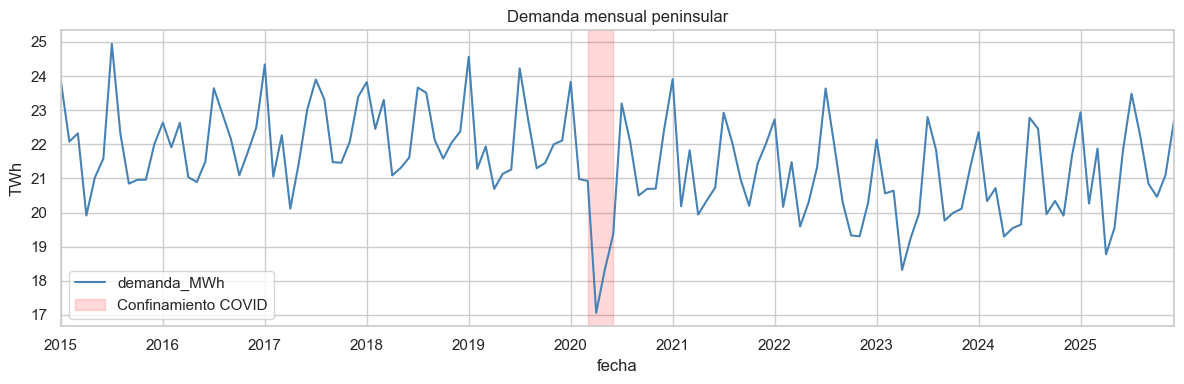

In [2]:
fig, ax = plt.subplots(figsize=(12, 4))
(df['demanda_MWh'] / 1e6).plot(ax=ax, color='steelblue')
ax.set_title('Demanda mensual peninsular')
ax.set_ylabel('TWh')
ax.axvspan('2020-03-01', '2020-06-30', color='red', alpha=0.15, label='Confinamiento COVID')
ax.legend(loc='lower left')
plt.tight_layout()

## 2. Descomposición STL

Separa la serie en tendencia + estacionalidad + residuo. STL con `robust=True` es resistente a outliers (útil porque tenemos COVID).

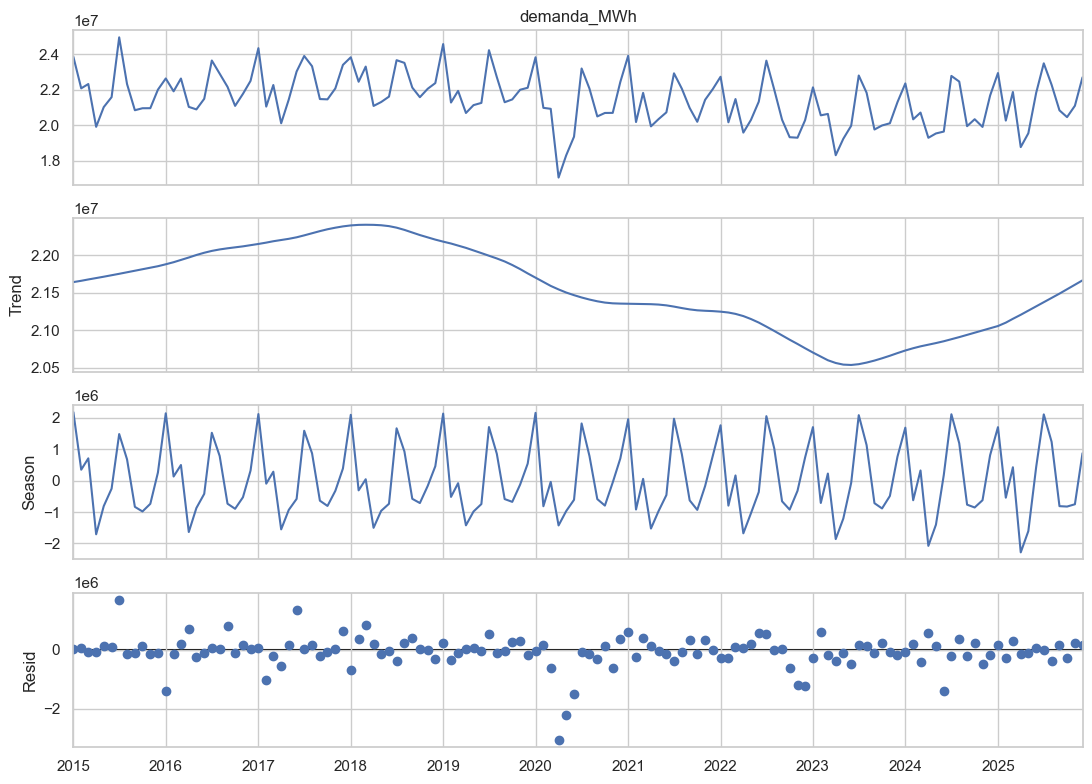

In [3]:
stl = STL(df['demanda_MWh'], period=12, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(11, 8)
plt.tight_layout()

## 3. ACF y PACF

Para orientar los órdenes de SARIMA. Con estacionalidad anual (12) esperamos picos a lag 12, 24, 36.

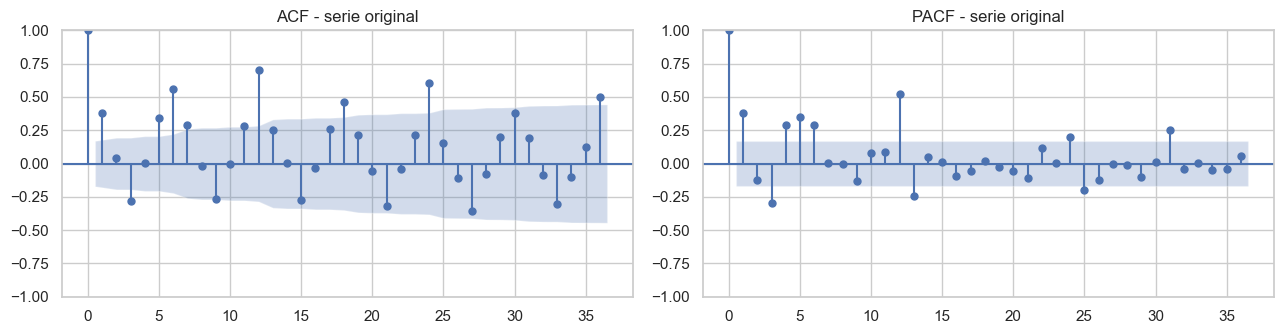

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
plot_acf(df['demanda_MWh'], lags=36, ax=axes[0])
axes[0].set_title('ACF - serie original')
plot_pacf(df['demanda_MWh'], lags=36, ax=axes[1], method='ywm')
axes[1].set_title('PACF - serie original')
plt.tight_layout()

## 4. Tests de estacionariedad

- **ADF** (H0: hay raíz unitaria → no estacionaria). p < 0.05 ⇒ estacionaria.
- **KPSS** (H0: estacionaria). p > 0.05 ⇒ estacionaria.

Ambos tests a la vez son más fiables que uno solo.

In [5]:
import warnings

def test_estacionariedad(serie, etiqueta):
    s = serie.dropna()
    adf_p = adfuller(s, autolag='AIC')[1]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        kpss_p = kpss(s, regression='c', nlags='auto')[1]
    veredicto_adf  = 'estacionaria' if adf_p  < 0.05 else 'NO estacionaria'
    veredicto_kpss = 'estacionaria' if kpss_p > 0.05 else 'NO estacionaria'
    print(f'{etiqueta:30} ADF p={adf_p:.4f} ({veredicto_adf})   KPSS p={kpss_p:.4f} ({veredicto_kpss})')

y = df['demanda_MWh']
test_estacionariedad(y,                       'Original')
test_estacionariedad(y.diff(1),               'd=1')
test_estacionariedad(y.diff(12),              'D=1 (estacional)')
test_estacionariedad(y.diff(12).diff(1),      'd=1 + D=1')

Original                       ADF p=0.6581 (NO estacionaria)   KPSS p=0.0100 (NO estacionaria)
d=1                            ADF p=0.0000 (estacionaria)   KPSS p=0.1000 (estacionaria)
D=1 (estacional)               ADF p=0.4493 (NO estacionaria)   KPSS p=0.1000 (estacionaria)
d=1 + D=1                      ADF p=0.0000 (estacionaria)   KPSS p=0.1000 (estacionaria)


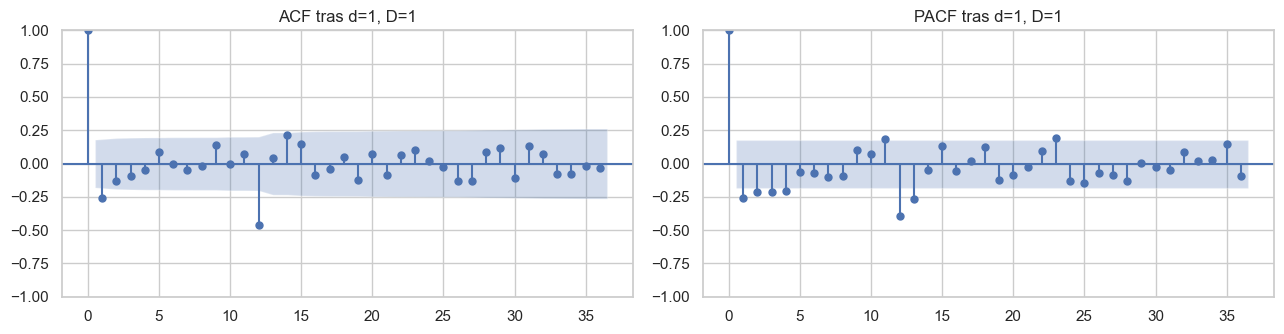

In [6]:
# ACF/PACF tras la diferenciacion que mejor estacionarice
y_diff = df['demanda_MWh'].diff(12).diff(1).dropna()
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
plot_acf(y_diff, lags=36, ax=axes[0])
axes[0].set_title('ACF tras d=1, D=1')
plot_pacf(y_diff, lags=36, ax=axes[1], method='ywm')
axes[1].set_title('PACF tras d=1, D=1')
plt.tight_layout()

## 5. Relación demanda - temperatura

Esperado: relación en U con temperatura media (frío y calor disparan demanda); positiva con HDD18 y CDD22.

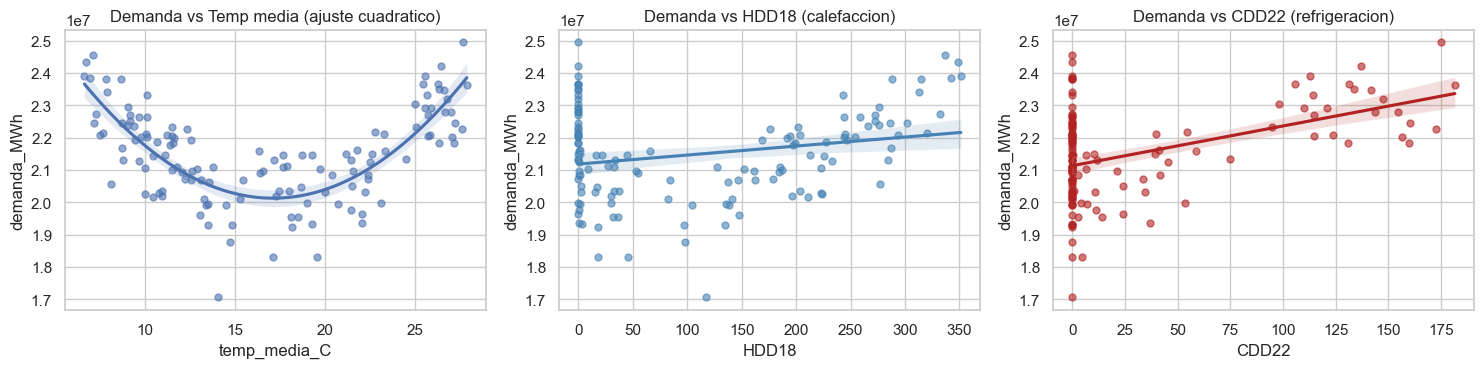

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.regplot(data=df, x='temp_media_C', y='demanda_MWh', order=2,
            ax=axes[0], scatter_kws={'alpha': 0.6, 's': 25})
axes[0].set_title('Demanda vs Temp media (ajuste cuadratico)')
sns.regplot(data=df, x='HDD18', y='demanda_MWh',
            ax=axes[1], scatter_kws={'alpha': 0.6, 's': 25}, color='steelblue')
axes[1].set_title('Demanda vs HDD18 (calefaccion)')
sns.regplot(data=df, x='CDD22', y='demanda_MWh',
            ax=axes[2], scatter_kws={'alpha': 0.6, 's': 25}, color='firebrick')
axes[2].set_title('Demanda vs CDD22 (refrigeracion)')
plt.tight_layout()

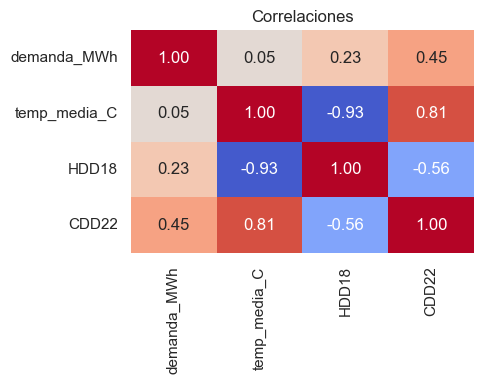

In [8]:
# Matriz de correlacion (Pearson)
corr = df[['demanda_MWh', 'temp_media_C', 'HDD18', 'CDD22']].corr()
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, cbar=False)
ax.set_title('Correlaciones')
plt.tight_layout()

## 6. Patrón estacional mes a mes

Boxplot por mes: dos picos al año (invierno y verano), valles en primavera/otoño.

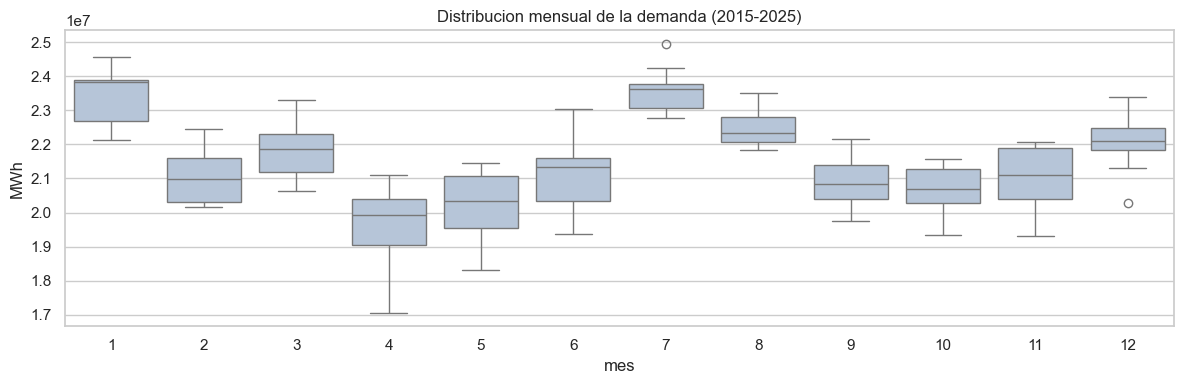

In [9]:
df_plot = df.copy()
df_plot['mes'] = df_plot.index.month
df_plot['anio'] = df_plot.index.year
fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(data=df_plot, x='mes', y='demanda_MWh', ax=ax, color='lightsteelblue')
ax.set_title('Distribucion mensual de la demanda (2015-2025)')
ax.set_ylabel('MWh')
plt.tight_layout()

## 7. Anomalía COVID y totales anuales

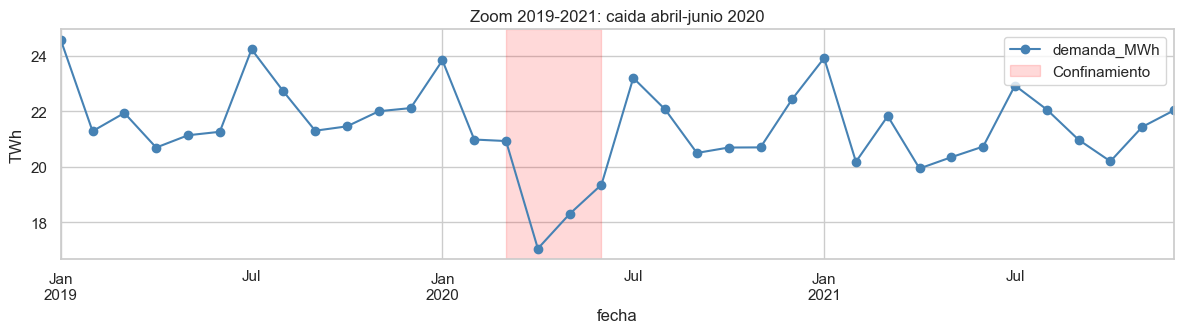

In [10]:
covid = df.loc['2019':'2021', 'demanda_MWh'] / 1e6
fig, ax = plt.subplots(figsize=(12, 3.5))
covid.plot(ax=ax, marker='o', color='steelblue')
ax.axvspan('2020-03-01', '2020-06-30', color='red', alpha=0.15, label='Confinamiento')
ax.set_title('Zoom 2019-2021: caida abril-junio 2020')
ax.set_ylabel('TWh')
ax.legend()
plt.tight_layout()

In [11]:
anual = df.resample('YE').agg(
    demanda_TWh=('demanda_MWh', lambda x: x.sum() / 1e6),
    HDD_anual=('HDD18', 'sum'),
    CDD_anual=('CDD22', 'sum'),
)
anual.index = anual.index.year
anual['var_yoy_%'] = anual['demanda_TWh'].pct_change() * 100
anual.round(2)

,demanda_TWh,HDD_anual,CDD_anual,var_yoy_%
fecha,,,,
2015,262.81,1409.51,337.88,NaN
2016,264.67,1458.98,345.94,0.71
2017,267.87,1384.49,342.36,1.21
2018,268.89,1530.48,320.46,0.38
2019,264.66,1395.08,309.38,-1.57
2020,250.05,1357.36,336.89,-5.52
2021,256.55,1425.80,280.17,2.60
2022,250.47,1280.61,458.44,-2.37
2023,246.67,1253.21,383.25,-1.52


## 8. Conclusiones para el modelado

- Estacionalidad anual fuerte (lag 12), confirmada por ACF y boxplot por mes → **D = 1** y `seasonal_periods = 12`.
- Tendencia con cambio de nivel claro en 2020 (COVID) → **d = 1** o tratamiento explícito de outlier.
- Relación demanda↔temperatura en U: HDD18 y CDD22 son mejores regresores que la temperatura cruda. CDD pesa más (verano A/C tira fuerte).
- 2020 será el fold más sucio en CV walk-forward (lo reportamos aparte).
- Próximo notebook (`02_modelado.ipynb`): SARIMA, SARIMAX (+HDD/CDD), ETS y Prophet con CV walk-forward de 4 folds y hold-out 2024-2025.